In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Reshape, Bidirectional, LSTM, Dense, Dropout
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import joblib
import matplotlib.pyplot as plt
import os
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Paths
FEATURES_DIR = '/content/drive/MyDrive/IIT/FYP/Implementation/data/Cough_Sound/mfcc_features'
MODEL_DIR = '/content/drive/MyDrive/IIT/FYP/Implementation/models/cough_sound'
os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
X_train = np.load(os.path.join(FEATURES_DIR, 'X_train_mfcc.npy'))
y_train = np.load(os.path.join(FEATURES_DIR, 'y_train.npy'))

X_val = np.load(os.path.join(FEATURES_DIR, 'X_val_mfcc.npy'))
y_val = np.load(os.path.join(FEATURES_DIR, 'y_val.npy'))

print("Train shape before flatten:", X_train.shape)
print("Val shape before flatten:", X_val.shape)

print(f"\nClass distribution:")
print(f"  Train - Pneumonia: {np.sum(y_train)} ({np.mean(y_train)*100:.1f}%), Normal: {len(y_train)-np.sum(y_train)} ({(1-np.mean(y_train))*100:.1f}%)")
print(f"  Val   - Pneumonia: {np.sum(y_val)} ({np.mean(y_val)*100:.1f}%), Normal: {len(y_val)-np.sum(y_val)} ({(1-np.mean(y_val))*100:.1f}%)")

Train shape before flatten: (1756, 100, 60)
Val shape before flatten: (83, 100, 60)

Class distribution:
  Train - Pneumonia: 892 (50.8%), Normal: 864 (49.2%)
  Val   - Pneumonia: 35 (42.2%), Normal: 48 (57.8%)


In [ ]:
# Flatten MFCC features
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

print("Train shape after flatten:", X_train_flat.shape)
print("Val shape after flatten:", X_val_flat.shape)

Train shape after flatten: (1756, 6000)
Val shape after flatten: (83, 6000)


In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}

print(f"Class Weights → Normal: {class_weight_dict[0]:.4f}, Pneumonia: {class_weight_dict[1]:.4f}")

Class Weights → Normal: 1.0162, Pneumonia: 0.9843


In [ ]:
def find_youdens_threshold(y_true, y_prob):
    """Find optimal threshold using Youden's J statistic on validation set."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    return thresholds[best_idx]

###SVM pipeline

In [ ]:
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=0.1,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

print("\nTraining SVM model...")
svm_model.fit(X_train_flat, y_train)


Training SVM model...


Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(C=0.1, class_weight='balanced', probability=True,
                     random_state=42))])


Evaluating SVM model...
Optimal Threshold (Youden's J, Val): 0.5980

Training Accuracy  : 0.7249
Validation Accuracy: 0.8072
Overfitting Gap    : -0.0823
Validation AUC     : 0.8565

Classification Report (Validation):
              precision    recall  f1-score   support

      Normal       0.77      0.96      0.85        48
   Pneumonia       0.91      0.60      0.72        35

    accuracy                           0.81        83
   macro avg       0.84      0.78      0.79        83
weighted avg       0.83      0.81      0.80        83



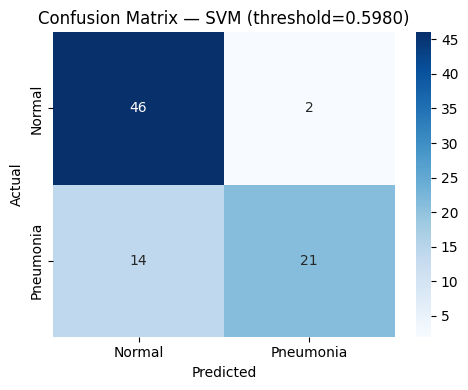

In [ ]:
print("\nEvaluating SVM model...")

# Probabilities on train and val
p_train_svm = svm_model.predict_proba(X_train_flat)[:, 1]
p_val_svm   = svm_model.predict_proba(X_val_flat)[:, 1]

# Youden's J threshold from VAL set
svm_threshold = find_youdens_threshold(y_val, p_val_svm)
print(f"Optimal Threshold (Youden's J, Val): {svm_threshold:.4f}")

# Predictions using optimal threshold
y_train_pred_svm = (p_train_svm >= svm_threshold).astype(int)
y_val_pred_svm   = (p_val_svm   >= svm_threshold).astype(int)

train_acc = accuracy_score(y_train, y_train_pred_svm)
val_acc   = accuracy_score(y_val,   y_val_pred_svm)
val_auc   = roc_auc_score(y_val,    p_val_svm)

print(f"\nTraining Accuracy  : {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Overfitting Gap    : {(train_acc - val_acc):.4f}")
print(f"Validation AUC     : {val_auc:.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred_svm, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_val, y_val_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title(f'Confusion Matrix — SVM (threshold={svm_threshold:.4f})')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

In [ ]:
svm_path = os.path.join(MODEL_DIR, 'mfcc_svm_model.pkl')
joblib.dump(svm_model, svm_path)

print(f"SVM model saved: {svm_path}")

SVM model saved: /content/drive/MyDrive/IIT/FYP/Implementation/models/cough_sound/mfcc_svm_model.pkl


###MFCC + LSTM

In [ ]:
# Model definition
input_shape = X_train.shape[1:]  # (timesteps, n_mfcc)
print(f"Input shape: {input_shape}")

inputs = Input(shape=input_shape)
x = LSTM(96, return_sequences=False, name='lstm_feature_layer',
         kernel_regularizer=keras.regularizers.l2(0.005))(inputs)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu', name='dense_feature_layer',
          kernel_regularizer=keras.regularizers.l2(0.005))(x)
x = Dropout(0.4)(x)
outputs = Dense(1, activation='sigmoid', name='output')(x)

model = Model(inputs, outputs)

# Better optimizer with learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

model.summary()

Input shape: (100, 60)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_feature_layer (LSTM)       │ (None, 96)             │        60,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature_layer (Dense)     │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,561 (260.00 KB)

 Trainable params: 66,561 (260.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'mfcc_lstm_best1.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
# Training
print("\nTraining MFCC + LSTM model...")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n Training completed")


Training MFCC + LSTM model...
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5173 - loss: 1.4776 - precision: 0.5175 - recall: 0.4931
Epoch 1: val_accuracy improved from -inf to 0.71084, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/cough_sound/mfcc_lstm_best1.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5173 - loss: 1.4751 - precision: 0.5178 - recall: 0.4928 - val_accuracy: 0.7108 - val_loss: 1.0685 - val_precision: 0.7200 - val_recall: 0.5143 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5539 - loss: 1.0321 - precision: 0.5634 - recall: 0.6263
Epoch 2: val_accuracy did not improve from 0.71084
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5538 - loss: 1.0314 - precision: 0.5632 - recall: 0.6255 - val_accuracy: 0.5904 - val_loss: 0.8964 - val_precision: 0.5556 - val_recall: 0.1429 - learning_rate: 0.0010
Epoch 3/100
50/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5953 - l

In [ ]:
# Load best model
print("\nLoading best model...")
model = keras.models.load_model(os.path.join(MODEL_DIR, 'mfcc_lstm_best1.keras'))


Loading best model...



Evaluating LSTM model...
Optimal Threshold (Youden's J, Val): 0.4964

Training Accuracy  : 0.9123
Validation Accuracy: 0.7590
Overfitting Gap    : 0.1533
Validation AUC     : 0.7815

Classification Report (Validation):
              precision    recall  f1-score   support

      Normal       0.83      0.73      0.78        48
   Pneumonia       0.68      0.80      0.74        35

    accuracy                           0.76        83
   macro avg       0.76      0.76      0.76        83
weighted avg       0.77      0.76      0.76        83



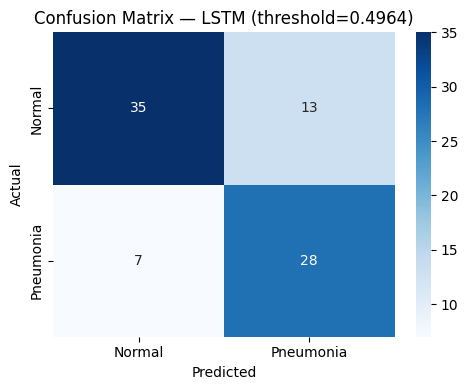

In [ ]:
print("\nEvaluating LSTM model...")

model_lstm = keras.models.load_model(os.path.join(MODEL_DIR, 'mfcc_lstm_best1.keras'))

# Probabilities
p_train_lstm = model_lstm.predict(X_train, verbose=0).flatten()
p_val_lstm   = model_lstm.predict(X_val,   verbose=0).flatten()

# Youden's J threshold from VAL set
lstm_threshold = find_youdens_threshold(y_val, p_val_lstm)
print(f"Optimal Threshold (Youden's J, Val): {lstm_threshold:.4f}")

y_train_pred_lstm = (p_train_lstm >= lstm_threshold).astype(int)
y_val_pred_lstm   = (p_val_lstm   >= lstm_threshold).astype(int)

train_acc = accuracy_score(y_train, y_train_pred_lstm)
val_acc   = accuracy_score(y_val,   y_val_pred_lstm)
val_auc   = roc_auc_score(y_val,    p_val_lstm)

print(f"\nTraining Accuracy  : {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Overfitting Gap    : {(train_acc - val_acc):.4f}")
print(f"Validation AUC     : {val_auc:.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred_lstm, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_val, y_val_pred_lstm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title(f'Confusion Matrix — LSTM (threshold={lstm_threshold:.4f})')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

###MFCC + BiLSTM model

In [ ]:
time_steps = X_train.shape[1]
n_mfcc = X_train.shape[2]

print(f"Time steps: {time_steps}, MFCC coefficients: {n_mfcc}")

Time steps: 100, MFCC coefficients: 60


In [ ]:
# BiLSTM model definition
input_shape = X_train.shape[1:]  # (timesteps, n_mfcc)
print(f"Input shape: {input_shape}")
inputs = Input(shape=input_shape, name='mfcc_input')

# First BiLSTM layer
x = Bidirectional(
    LSTM(128, return_sequences=True,
         kernel_regularizer=keras.regularizers.l2(0.001)),
    name='bilstm_1'
)(inputs)
x = Dropout(0.3)(x)

# Second BiLSTM layer
x = Bidirectional(
    LSTM(64, return_sequences=False,
         kernel_regularizer=keras.regularizers.l2(0.001)),
    name='bilstm_feature_layer'  # For fusion
)(x)
x = Dropout(0.4)(x)

# Dense layer
x = Dense(64, activation='relu',
          kernel_regularizer=keras.regularizers.l2(0.001),
          name='dense_feature_layer')(x)
x = Dropout(0.4)(x)

# Output layer
outputs = Dense(1, activation='sigmoid', name='output')(x)

model = Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

model.summary()

Input shape: (100, 60)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 100, 256)       │       193,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_feature_layer            │ (None, 128)            │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature_layer (Dense)     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 366,209 (1.40 MB)

 Trainable params: 366,209 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
checkpoint_path = os.path.join(MODEL_DIR, 'mfcc_bilstm_best1.keras')

callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
print("\nTraining MFCC + BiLSTM model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\nTraining completed")

# Load best model
print("\nLoading best model...")
model = keras.models.load_model(checkpoint_path)


Training MFCC + BiLSTM model...
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5319 - loss: 1.3950 - precision_1: 0.5539 - recall_1: 0.5238
Epoch 1: val_accuracy improved from -inf to 0.71084, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/cough_sound/mfcc_bilstm_best1.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.5322 - loss: 1.3926 - precision_1: 0.5539 - recall_1: 0.5243 - val_accuracy: 0.7108 - val_loss: 0.9860 - val_precision_1: 0.8667 - val_recall_1: 0.3714 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6547 - loss: 0.9921 - precision_1: 0.6816 - recall_1: 0.6384
Epoch 2: val_accuracy did not improve from 0.71084
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6552 - loss: 0.9913 - precision_1: 0.6817 - recall_1: 0.6393 - val_accuracy: 0.6386 - val_loss: 0.9133 - val_precision_1: 0.6190 - val_recall_1: 0.3714 - learning_rate: 0.0010
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 22


Evaluating BiLSTM model...
Optimal Threshold (Youden's J, Val): 0.2856

Training Accuracy  : 0.9732
Validation Accuracy: 0.7470
Overfitting Gap    : 0.2262
Validation AUC     : 0.7905

Classification Report (Validation):
              precision    recall  f1-score   support

      Normal       0.76      0.81      0.79        48
   Pneumonia       0.72      0.66      0.69        35

    accuracy                           0.75        83
   macro avg       0.74      0.73      0.74        83
weighted avg       0.75      0.75      0.75        83



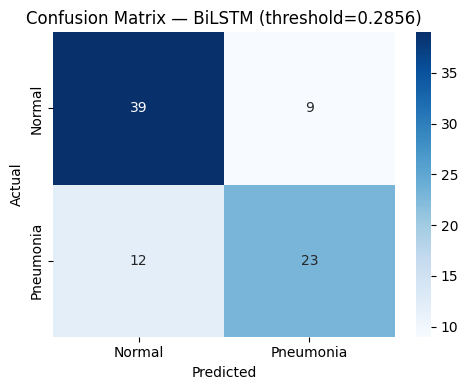

In [ ]:
print("\nEvaluating BiLSTM model...")

model_bilstm = keras.models.load_model(os.path.join(MODEL_DIR, 'mfcc_bilstm_best1.keras'))

# Probabilities
p_train_bilstm = model_bilstm.predict(X_train, verbose=0).flatten()
p_val_bilstm   = model_bilstm.predict(X_val,   verbose=0).flatten()

# Youden's J threshold from VAL set
bilstm_threshold = find_youdens_threshold(y_val, p_val_bilstm)
print(f"Optimal Threshold (Youden's J, Val): {bilstm_threshold:.4f}")

y_train_pred_bilstm = (p_train_bilstm >= bilstm_threshold).astype(int)
y_val_pred_bilstm   = (p_val_bilstm   >= bilstm_threshold).astype(int)

train_acc = accuracy_score(y_train, y_train_pred_bilstm)
val_acc   = accuracy_score(y_val,   y_val_pred_bilstm)
val_auc   = roc_auc_score(y_val,    p_val_bilstm)

print(f"\nTraining Accuracy  : {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Overfitting Gap    : {(train_acc - val_acc):.4f}")
print(f"Validation AUC     : {val_auc:.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred_bilstm, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_val, y_val_pred_bilstm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title(f'Confusion Matrix — BiLSTM (threshold={bilstm_threshold:.4f})')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

###CNN + BiLSTM Model

In [ ]:
# X_train shape is (1756, 100, 60) → add channel dim → (1756, 100, 60, 1)
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn   = X_val[..., np.newaxis]

print("CNN input shape - Train:", X_train_cnn.shape)
print("CNN input shape - Val  :", X_val_cnn.shape)

CNN input shape - Train: (1756, 100, 60, 1)
CNN input shape - Val  : (83, 100, 60, 1)


In [ ]:
def build_cnn_bilstm(input_shape=(100, 60, 1)):
    inputs = Input(shape=input_shape, name='mfcc_input')

    # --- CNN Block 1 ---
    x = Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(1e-4), name='conv1')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # --- CNN Block 2 ---
    x = Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(1e-4), name='conv2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # --- Reshape for BiLSTM ---
    # After 2 MaxPool(2,2): (100→25, 60→15), 64 filters
    # Shape becomes (batch, 25, 15*64) = (batch, 25, 960)
    shape = x.shape
    time_steps = shape[1]
    features   = shape[2] * shape[3]
    x = Reshape((time_steps, features), name='reshape_to_sequence')(x)

    # --- BiLSTM ---
    x = Bidirectional(LSTM(64, return_sequences=False,
                           kernel_regularizer=l2(1e-4)),
                      name='bilstm')(x)
    x = Dropout(0.4)(x)

    # --- Dense Head ---
    x = Dense(64, activation='relu',
              kernel_regularizer=l2(1e-4), name='dense_feature_layer')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, outputs, name='CNN_BiLSTM')
    return model


cnn_bilstm_model = build_cnn_bilstm(input_shape=(100, 60, 1))
cnn_bilstm_model.summary()


Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 100, 60, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 100, 60, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 60, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 50, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_to_sequence (Reshape)   │ (None, 25, 960)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature_layer (Dense)     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 552,321 (2.11 MB)

 Trainable params: 552,129 (2.11 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# compile
cnn_bilstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

In [ ]:
# callbacks
cnn_bilstm_callbacks = [
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'mfcc_cnn_bilstm_best2.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
# Train
print("\nTraining CNN + BiLSTM model...")

cnn_bilstm_history = cnn_bilstm_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    callbacks=cnn_bilstm_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\nTraining completed")


Training CNN + BiLSTM model...
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8231 - auc: 0.9005 - loss: 0.4603
Epoch 1: val_accuracy improved from None to 0.72289, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/cough_sound/mfcc_cnn_bilstm_best2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/cough_sound/mfcc_cnn_bilstm_best2.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8178 - auc: 0.8987 - loss: 0.4639 - val_accuracy: 0.7229 - val_auc: 0.8586 - val_loss: 0.5385 - learning_rate: 2.5000e-04
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8308 - auc: 0.9148 - loss: 0.4362
Epoch 2: val_accuracy improved from 0.72289 to 0.75904, saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/cough_sound/mfcc_cnn_bilstm_best2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/IIT/FYP/Implementation/models/cough_sound/mfcc_cnn_bilstm_best2.keras
55/55 ━━━


Evaluating CNN-BiLSTM model...
Optimal Threshold (Youden's J, Val): 0.4295

Training Accuracy  : 0.6845
Validation Accuracy: 0.8554
Overfitting Gap    : -0.1709
Validation AUC     : 0.8911

Classification Report (Validation):
              precision    recall  f1-score   support

      Normal       0.85      0.92      0.88        48
   Pneumonia       0.87      0.77      0.82        35

    accuracy                           0.86        83
   macro avg       0.86      0.84      0.85        83
weighted avg       0.86      0.86      0.85        83



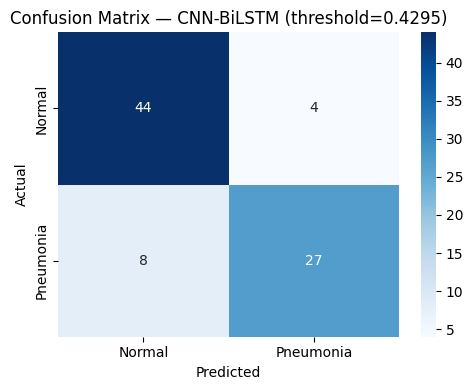

In [ ]:
print("\nEvaluating CNN-BiLSTM model...")

model_cnn = keras.models.load_model(os.path.join(MODEL_DIR, 'mfcc_cnn_bilstm_best2.keras'))

# CNN input needs channel dim
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn   = X_val[..., np.newaxis]

# Probabilities
p_train_cnn = model_cnn.predict(X_train_cnn, verbose=0).flatten()
p_val_cnn   = model_cnn.predict(X_val_cnn,   verbose=0).flatten()

#  Youden's J threshold from VAL set
cnn_threshold = find_youdens_threshold(y_val, p_val_cnn)
print(f"Optimal Threshold (Youden's J, Val): {cnn_threshold:.4f}")

y_train_pred_cnn = (p_train_cnn >= cnn_threshold).astype(int)
y_val_pred_cnn   = (p_val_cnn   >= cnn_threshold).astype(int)

train_acc = accuracy_score(y_train, y_train_pred_cnn)
val_acc   = accuracy_score(y_val,   y_val_pred_cnn)
val_auc   = roc_auc_score(y_val,    p_val_cnn)

print(f"\nTraining Accuracy  : {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Overfitting Gap    : {(train_acc - val_acc):.4f}")
print(f"Validation AUC     : {val_auc:.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred_cnn, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_val, y_val_pred_cnn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title(f'Confusion Matrix — CNN-BiLSTM (threshold={cnn_threshold:.4f})')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

In [ ]:
# ── Full Model Comparison Table ────────────────────────────────────────────
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

results = {
    'Model': [
        'SVM + MFCC',
        'LSTM + MFCC',
        'BiLSTM + MFCC',
        'CNN-BiLSTM + MFCC'
    ],
    'Val Accuracy': [
        accuracy_score(y_val, y_val_pred_svm),
        accuracy_score(y_val, y_val_pred_lstm),
        accuracy_score(y_val, y_val_pred_bilstm),
        accuracy_score(y_val, y_val_pred_cnn)
    ],
    'Val AUC': [
        roc_auc_score(y_val, p_val_svm),
        roc_auc_score(y_val, p_val_lstm),
        roc_auc_score(y_val, p_val_bilstm),
        roc_auc_score(y_val, p_val_cnn)
    ],
    'Overfitting Gap': [
        accuracy_score(y_train, y_train_pred_svm)   - accuracy_score(y_val, y_val_pred_svm),
        accuracy_score(y_train, y_train_pred_lstm)  - accuracy_score(y_val, y_val_pred_lstm),
        accuracy_score(y_train, y_train_pred_bilstm)- accuracy_score(y_val, y_val_pred_bilstm),
        accuracy_score(y_train, y_train_pred_cnn)   - accuracy_score(y_val, y_val_pred_cnn)
    ],
    'Precision (Pneu)': [
        precision_score(y_val, y_val_pred_svm),
        precision_score(y_val, y_val_pred_lstm),
        precision_score(y_val, y_val_pred_bilstm),
        precision_score(y_val, y_val_pred_cnn)
    ],
    'Recall (Pneu)': [
        recall_score(y_val, y_val_pred_svm),
        recall_score(y_val, y_val_pred_lstm),
        recall_score(y_val, y_val_pred_bilstm),
        recall_score(y_val, y_val_pred_cnn)
    ],
    'F1 (Pneu)': [
        f1_score(y_val, y_val_pred_svm),
        f1_score(y_val, y_val_pred_lstm),
        f1_score(y_val, y_val_pred_bilstm),
        f1_score(y_val, y_val_pred_cnn)
    ],
    'Threshold': [
        round(svm_threshold, 4),
        round(lstm_threshold, 4),
        round(bilstm_threshold, 4),
        round(cnn_threshold, 4)
    ]
}

df = pd.DataFrame(results)

# Round numeric columns
numeric_cols = ['Val Accuracy', 'Val AUC', 'Overfitting Gap',
                'Precision (Pneu)', 'Recall (Pneu)', 'F1 (Pneu)']
df[numeric_cols] = df[numeric_cols].round(4)

# ── Print plain table
print("\n" + "="*95)
print("  COUGH MODEL COMPARISON — Validation Set (Youden's J Threshold)")
print("="*95)
print(df.to_string(index=False))
print("="*95)

# ── Highlight best values
print("\n Best Values:")
print(f"  Highest Val Accuracy  : {df.loc[df['Val Accuracy'].idxmax(), 'Model']}  →  {df['Val Accuracy'].max():.4f}")
print(f"  Highest Val AUC       : {df.loc[df['Val AUC'].idxmax(), 'Model']}  →  {df['Val AUC'].max():.4f}")
print(f"  Lowest Overfit Gap    : {df.loc[df['Overfitting Gap'].idxmin(), 'Model']}  →  {df['Overfitting Gap'].min():.4f}")
print(f"  Highest Pneu Recall   : {df.loc[df['Recall (Pneu)'].idxmax(), 'Model']}  →  {df['Recall (Pneu)'].max():.4f}")
print(f"  Highest Pneu F1       : {df.loc[df['F1 (Pneu)'].idxmax(), 'Model']}  →  {df['F1 (Pneu)'].max():.4f}")

def highlight_best(s):
    """Highlight max green for accuracy/AUC/recall/F1,
       highlight min green for overfitting gap."""
    styles = [''] * len(s)
    if s.name in ['Val Accuracy', 'Val AUC',
                  'Precision (Pneu)', 'Recall (Pneu)', 'F1 (Pneu)']:
        best_idx = s.idxmax()
        styles[best_idx] = 'background-color: #90EE90; font-weight: bold'
    elif s.name == 'Overfitting Gap':
        best_idx = s.idxmin()
        styles[best_idx] = 'background-color: #90EE90; font-weight: bold'
    return styles

styled_df = (df.style
               .apply(highlight_best, subset=numeric_cols)
               .set_caption("Cough Model Comparison — Validation Set (Youden's J Threshold)"))

display(styled_df)



  COUGH MODEL COMPARISON — Validation Set (Youden's J Threshold)
            Model  Val Accuracy  Val AUC  Overfitting Gap  Precision (Pneu)  Recall (Pneu)  F1 (Pneu)  Threshold
       SVM + MFCC        0.8072   0.8565          -0.0823            0.9130         0.6000     0.7241     0.5980
      LSTM + MFCC        0.7590   0.7815           0.1533            0.6829         0.8000     0.7368     0.4964
    BiLSTM + MFCC        0.7470   0.7905           0.2262            0.7188         0.6571     0.6866     0.2856
CNN-BiLSTM + MFCC        0.8554   0.8911          -0.1709            0.8710         0.7714     0.8182     0.4295

 Best Values:
  Highest Val Accuracy  : CNN-BiLSTM + MFCC  →  0.8554
  Highest Val AUC       : CNN-BiLSTM + MFCC  →  0.8911
  Lowest Overfit Gap    : CNN-BiLSTM + MFCC  →  -0.1709
  Highest Pneu Recall   : LSTM + MFCC  →  0.8000
  Highest Pneu F1       : CNN-BiLSTM + MFCC  →  0.8182


,Model,Val Accuracy,Val AUC,Overfitting Gap,Precision (Pneu),Recall (Pneu),F1 (Pneu),Threshold
0,SVM + MFCC,0.807200,0.856500,-0.082300,0.913000,0.600000,0.724100,0.598000
1,LSTM + MFCC,0.759000,0.781500,0.153300,0.682900,0.800000,0.736800,0.496400
2,BiLSTM + MFCC,0.747000,0.790500,0.226200,0.718800,0.657100,0.686600,0.285600
3,CNN-BiLSTM + MFCC,0.855400,0.891100,-0.170900,0.871000,0.771400,0.818200,0.429500


##CNN-BiLSTM Test Set Evaluation

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
import seaborn as sns

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/IIT/FYP/Implementation/models/cough_sound/mfcc_cnn_bilstm_best2.keras'

In [ ]:
# Load test data
X_test = np.load(f'{FEATURES_DIR}/X_test_mfcc.npy')
y_test = np.load(f'{FEATURES_DIR}/y_test.npy')

print(f"Test shape  : {X_test.shape}")
print(f"Test labels : Pneumonia={int(y_test.sum())}  Normal={int((y_test==0).sum())}")

Test shape  : (77, 100, 60)
Test labels : Pneumonia=41  Normal=36


In [ ]:
# Add channel dimension for CNN
X_test_cnn = X_test[..., np.newaxis]          # (77, 100, 60, 1)
print(f"CNN input shape: {X_test_cnn.shape}")

CNN input shape: (77, 100, 60, 1)


In [ ]:
# Load model
model = keras.models.load_model(MODEL_PATH)

# Predict probabilities
p_test = model.predict(X_test_cnn, verbose=0).flatten()

# USE validation threshold
THRESHOLD = 0.4295
print(f"\nUsing Validation Threshold: {THRESHOLD:.4f}")


Using Validation Threshold: 0.4295


In [ ]:
# apply optimal threshold
y_pred = (p_test >= THRESHOLD).astype(int)


acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, p_test)

In [ ]:
print("=" * 47)
print("  CNN-BiLSTM (MFCC) — Test Set Evaluation")
print("=" * 47)
print(f"  Accuracy             : {acc:.4f}")
print(f"  Precision            : {precision:.4f}")
print(f"  Recall (Sensitivity) : {recall:.4f}")
print(f"  F1-Score             : {f1:.4f}")
print(f"  ROC-AUC              : {auc:.4f}")
print("=" * 47)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred,
                            target_names=["Normal", "Pneumonia"]))

  CNN-BiLSTM (MFCC) — Test Set Evaluation
  Accuracy             : 0.7403
  Precision            : 0.8182
  Recall (Sensitivity) : 0.6585
  F1-Score             : 0.7297
  ROC-AUC              : 0.7459

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.68      0.83      0.75        36
   Pneumonia       0.82      0.66      0.73        41

    accuracy                           0.74        77
   macro avg       0.75      0.75      0.74        77
weighted avg       0.75      0.74      0.74        77



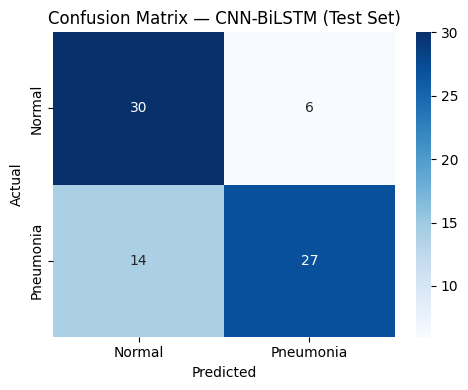

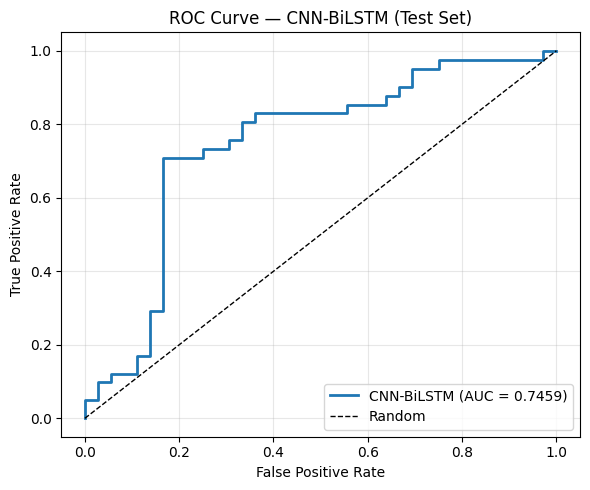

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"])
plt.title("Confusion Matrix — CNN-BiLSTM (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, p_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2,
         label=f'CNN-BiLSTM (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — CNN-BiLSTM (Test Set)")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
